In [2]:
pip install -U mplhep

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install "numpy>=2.0,<2.3" --force-reinstall

  Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
Note: you may need to restart the kernel to use updated packages.


In [1]:
# python
import sys
import os
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local

sidm_path = str(os.getcwd()).split("/sidm")[0]
# sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, cutflow
from sidm.tools import llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
from tqdm.notebook import tqdm
import coffea.util
import numpy as np
import mplhep as hep
import yaml
from sidm.tools.utilities import get_cut_yield, print_CR_yield, extract_cutflow_yields, plot_cutflow_panels
from pathlib import Path

In [2]:
# Load signal sample names from YAML files
yaml_file_path = "../../configs/ntuples/signal_2mu2e_v10.yaml"
with open(yaml_file_path, "r") as file:
    data = yaml.safe_load(file)

signals_2mu2e_all = list(
    data["llpNanoAOD_v2"]["samples"].keys()
)

yaml_file_path = "../../configs/ntuples/signal_4mu_v10.yaml"
with open(yaml_file_path, "r") as file:
    data = yaml.safe_load(file)

signals_4mu_all = list(
    data["llpNanoAOD_v2"]["samples"].keys()
)


# Combine all signal samples
signals_all = signals_2mu2e_all + signals_4mu_all


# Check whether an out dictionary already exists
try:
    out
    print(
        "The out dictionary already exists; "
        "will use what is saved in memory if possible"
    )
except NameError:
    print(
        "WARNING! No processor output stored in memory. "
        "Will load one coffea file for each sample."
    )
    out = {}

input_dir = Path("1LJ_CR_signal_full_merge")


# Load one merged coffea file for each signal point
for sample in signals_all:
    if sample in out:
        print(f"{sample} already found in memory; not loading file")
        continue

    input_file = input_dir / f"{sample}.coffea"
    print(f"Loading {input_file}")

    try:
        output = coffea.util.load(input_file)
    except FileNotFoundError:
        print(f"**** File not found: {input_file}")
        continue
    except Exception as error:
        print(f"**** Failed to load {input_file}: {error}")
        continue

    # Support the possible output structures:
    # output["out"][sample] or output[sample]
    if "out" in output and sample in output["out"]:
        out[sample] = output["out"][sample]
    elif sample in output:
        out[sample] = output[sample]
    else:
        print(
            f"**** Sample '{sample}' was not found inside "
            f"{input_file}"
        )
        print(f"Available top-level keys: {list(output.keys())}")
        continue

    print(f"Successfully loaded {sample}")

WARNING! No processor output stored in memory. Will load one coffea file for each sample.
Loading 1LJ_CR_signal_full_merge/2Mu2E_100GeV_0p25GeV_0p02mm.coffea
Successfully loaded 2Mu2E_100GeV_0p25GeV_0p02mm
Loading 1LJ_CR_signal_full_merge/2Mu2E_100GeV_0p25GeV_0p2mm.coffea
Successfully loaded 2Mu2E_100GeV_0p25GeV_0p2mm
Loading 1LJ_CR_signal_full_merge/2Mu2E_100GeV_0p25GeV_2p0mm.coffea
Successfully loaded 2Mu2E_100GeV_0p25GeV_2p0mm
Loading 1LJ_CR_signal_full_merge/2Mu2E_100GeV_0p25GeV_10p0mm.coffea
Successfully loaded 2Mu2E_100GeV_0p25GeV_10p0mm
Loading 1LJ_CR_signal_full_merge/2Mu2E_100GeV_0p25GeV_20p0mm.coffea
Successfully loaded 2Mu2E_100GeV_0p25GeV_20p0mm
Loading 1LJ_CR_signal_full_merge/2Mu2E_100GeV_1p2GeV_0p096mm.coffea
Successfully loaded 2Mu2E_100GeV_1p2GeV_0p096mm
Loading 1LJ_CR_signal_full_merge/2Mu2E_100GeV_1p2GeV_0p96mm.coffea
Successfully loaded 2Mu2E_100GeV_1p2GeV_0p96mm
Loading 1LJ_CR_signal_full_merge/2Mu2E_100GeV_1p2GeV_9p6mm.coffea
Successfully loaded 2Mu2E_100GeV_1p2Ge

In [3]:
samples_bkg = [
    "TTJets",
    "QCD_Pt15To20",
    "QCD_Pt20To30",
    "QCD_Pt30To50",
    "QCD_Pt50To80",
    "QCD_Pt80To120", 
    "QCD_Pt120To170",
    "QCD_Pt170To300", 
    "QCD_Pt300To470",
    "QCD_Pt470To600", 
    "QCD_Pt600To800", 
    "QCD_Pt800To1000",
    "QCD_Pt1000", 
    "DYJetsToLL_M10to50",
    "DYJetsToLL_M50", 
    "WW",
    "WZ",
    "ZZ",
]

In [4]:
#First check if there is already an out dictionary
try:
    out
    print("The _out_ dictionary already exists; will use what is saved in memory if possible")
except NameError:
    print("WARNING! No processor output stored in the kernel's memory. Will try to load pickled coffea file for each sample instead")
    out = {}

#For each sample, try to use the data in memory if possible; if not try to load the file
#If those both fail, then raise an error and skip it
for sample in samples_bkg:
    if sample in out:
        print(f"{sample} already found in memory; not loading file")
    else:
        print(f"Loading file for sample {sample}")
        filename = sample + ".coffea"
        try: 
            output = coffea.util.load("1LJ_CR_bkg_full_merge/"+filename)
            print("Successfully opened file")        
            out[sample] = output["out"][sample]
            # out[sample] = output["out"][sample.removesuffix("_part1")]
        except Exception:
            out[sample] = output[sample]
            # print("**** ERROR! File not found. Check the file name, or run the processor again and save the output to a pickle file using coffea.util.save")

The _out_ dictionary already exists; will use what is saved in memory if possible
Loading file for sample TTJets
Successfully opened file
Loading file for sample QCD_Pt15To20
Successfully opened file
Loading file for sample QCD_Pt20To30
Successfully opened file
Loading file for sample QCD_Pt30To50
Successfully opened file
Loading file for sample QCD_Pt50To80
Successfully opened file
Loading file for sample QCD_Pt80To120
Successfully opened file
Loading file for sample QCD_Pt120To170
Successfully opened file
Loading file for sample QCD_Pt170To300
Successfully opened file
Loading file for sample QCD_Pt300To470
Successfully opened file
Loading file for sample QCD_Pt470To600
Successfully opened file
Loading file for sample QCD_Pt600To800
Successfully opened file
Loading file for sample QCD_Pt800To1000
Successfully opened file
Loading file for sample QCD_Pt1000
Successfully opened file
Loading file for sample DYJetsToLL_M10to50
Successfully opened file
Loading file for sample DYJetsToLL_M50

In [5]:
channels = [
    "data_control_region_1egmLj",
]

In [6]:
result = print_CR_yield(
    out,
    signals_2mu2e_all,
    samples_bkg,
    cut_name="= 1 egmLJs",
    channel=channels[0],
    weighted=True,
    cumulative=True,
)

=== Signal yields ===
2Mu2E_100GeV_0p25GeV_0p02mm         : 0.058060
2Mu2E_100GeV_0p25GeV_0p2mm          : 0.073794
2Mu2E_100GeV_0p25GeV_2p0mm          : 0.341109
2Mu2E_100GeV_0p25GeV_10p0mm         : 0.311508
2Mu2E_100GeV_0p25GeV_20p0mm         : 0.203232
2Mu2E_100GeV_1p2GeV_0p096mm         : 0.018499
2Mu2E_100GeV_1p2GeV_0p96mm          : 0.033697
2Mu2E_100GeV_1p2GeV_9p6mm           : 0.169872
2Mu2E_100GeV_1p2GeV_48p0mm          : 0.174916
2Mu2E_100GeV_1p2GeV_96p0mm          : 0.117679
2Mu2E_100GeV_5p0GeV_0p4mm           : 0.013768
2Mu2E_100GeV_5p0GeV_4p0mm           : 0.027856
2Mu2E_100GeV_5p0GeV_40p0mm          : 0.216368
2Mu2E_100GeV_5p0GeV_200mm           : 0.279693
2Mu2E_100GeV_5p0GeV_400mm           : 0.180583
2Mu2E_150GeV_0p25GeV_0p013mm        : 0.062328
2Mu2E_150GeV_0p25GeV_0p13mm         : 0.126841
2Mu2E_150GeV_0p25GeV_1p3mm          : 0.634673
2Mu2E_150GeV_0p25GeV_6p7mm          : 0.583214
2Mu2E_150GeV_0p25GeV_13p0mm         : 0.357156
2Mu2E_150GeV_1p2GeV_0p064mm         : 

In [7]:
result = print_CR_yield(
    out,
    signals_4mu_all,
    samples_bkg,
    cut_name="= 1 egmLJs",
    channel=channels[0],
    weighted=True,
    cumulative=True,
)

=== Signal yields ===
4Mu_100GeV_0p25GeV_0p02mm           : 0.000000
4Mu_100GeV_0p25GeV_0p2mm            : 0.000000
4Mu_100GeV_0p25GeV_2p0mm            : 0.000665
4Mu_100GeV_0p25GeV_10p0mm           : 0.003016
4Mu_100GeV_0p25GeV_20p0mm           : 0.004037
4Mu_100GeV_1p2GeV_0p096mm           : 0.000000
4Mu_100GeV_1p2GeV_0p96mm            : 0.000000
4Mu_100GeV_1p2GeV_9p6mm             : 0.000719
4Mu_100GeV_1p2GeV_48p0mm            : 0.003274
4Mu_100GeV_1p2GeV_96p0mm            : 0.005173
4Mu_100GeV_5p0GeV_0p4mm             : 0.000808
4Mu_100GeV_5p0GeV_4p0mm             : 0.000946
4Mu_100GeV_5p0GeV_40p0mm            : 0.005239
4Mu_100GeV_5p0GeV_200mm             : 0.003403
4Mu_100GeV_5p0GeV_400mm             : 0.002848
4Mu_150GeV_0p25GeV_0p013mm          : 0.000000
4Mu_150GeV_0p25GeV_0p13mm           : 0.000000
4Mu_150GeV_0p25GeV_1p3mm            : 0.000951
4Mu_150GeV_0p25GeV_6p7mm            : 0.006181
4Mu_150GeV_0p25GeV_13p0mm           : 0.006652
4Mu_150GeV_1p2GeV_0p064mm           : 

In [8]:
group1_2mu2e = [
    "2Mu2E_100GeV_0p25GeV_0p02mm",
    "2Mu2E_100GeV_0p25GeV_20p0mm",
    "2Mu2E_100GeV_1p2GeV_0p096mm",
    "2Mu2E_100GeV_1p2GeV_96p0mm",
    "2Mu2E_100GeV_5p0GeV_0p4mm",
    "2Mu2E_100GeV_5p0GeV_400mm",
]

group2_2mu2e = [
    "2Mu2E_150GeV_0p25GeV_0p013mm",
    "2Mu2E_150GeV_0p25GeV_13p0mm",
    "2Mu2E_150GeV_1p2GeV_0p064mm",
    "2Mu2E_150GeV_1p2GeV_64p0mm",
    "2Mu2E_150GeV_5p0GeV_0p27mm",
    "2Mu2E_150GeV_5p0GeV_270p0mm",
]

group3_2mu2e = [
    "2Mu2E_200GeV_0p25GeV_0p01mm",
    "2Mu2E_200GeV_0p25GeV_10p0mm",
    "2Mu2E_200GeV_1p2GeV_0p048mm",
    "2Mu2E_200GeV_1p2GeV_48p0mm",
    "2Mu2E_200GeV_5p0GeV_0p2mm",
    "2Mu2E_200GeV_5p0GeV_200p0mm",
]

group4_2mu2e = [
    "2Mu2E_500GeV_0p25GeV_0p004mm",
    "2Mu2E_500GeV_0p25GeV_4p0mm",
    "2Mu2E_500GeV_1p2GeV_0p019mm",
    "2Mu2E_500GeV_1p2GeV_19p0mm",
    "2Mu2E_500GeV_5p0GeV_0p08mm",
    "2Mu2E_500GeV_5p0GeV_80p0mm",
]

group5_2mu2e = [
    "2Mu2E_800GeV_0p25GeV_0p0025mm",
    "2Mu2E_800GeV_0p25GeV_2p5mm",
    "2Mu2E_800GeV_1p2GeV_0p012mm",
    "2Mu2E_800GeV_1p2GeV_12p0mm",
    "2Mu2E_800GeV_5p0GeV_0p05mm",
    "2Mu2E_800GeV_5p0GeV_50p0mm",
]

group6_2mu2e = [
    "2Mu2E_1000GeV_0p25GeV_0p002mm",
    "2Mu2E_1000GeV_0p25GeV_2p0mm",
    "2Mu2E_1000GeV_1p2GeV_0p0096mm",
    "2Mu2E_1000GeV_1p2GeV_9p6mm",
    "2Mu2E_1000GeV_5p0GeV_0p04mm",
    "2Mu2E_1000GeV_5p0GeV_40p0mm",
]

In [9]:
group1_4mu = [
    "4Mu_100GeV_0p25GeV_0p02mm",
    "4Mu_100GeV_0p25GeV_20p0mm",
    "4Mu_100GeV_1p2GeV_0p096mm",
    "4Mu_100GeV_1p2GeV_96p0mm",
    "4Mu_100GeV_5p0GeV_0p4mm",
    "4Mu_100GeV_5p0GeV_400mm",
]

group2_4mu = [
    "4Mu_150GeV_0p25GeV_0p013mm",
    "4Mu_150GeV_0p25GeV_13p0mm",
    "4Mu_150GeV_1p2GeV_0p064mm",
    "4Mu_150GeV_1p2GeV_64p0mm",
    "4Mu_150GeV_5p0GeV_0p27mm",
    "4Mu_150GeV_5p0GeV_270p0mm",
]

group3_4mu = [
    "4Mu_200GeV_0p25GeV_0p01mm",
    "4Mu_200GeV_0p25GeV_10p0mm",
    "4Mu_200GeV_1p2GeV_0p048mm",
    "4Mu_200GeV_1p2GeV_48p0mm",
    "4Mu_200GeV_5p0GeV_0p2mm",
    "4Mu_200GeV_5p0GeV_200p0mm",
]

group4_4mu = [
    "4Mu_500GeV_0p25GeV_0p004mm",
    "4Mu_500GeV_0p25GeV_4p0mm",
    "4Mu_500GeV_1p2GeV_0p019mm",
    "4Mu_500GeV_1p2GeV_19p0mm",
    "4Mu_500GeV_5p0GeV_0p08mm",
    "4Mu_500GeV_5p0GeV_80p0mm",
]

group5_4mu = [
    "4Mu_800GeV_0p25GeV_0p0025mm",
    "4Mu_800GeV_0p25GeV_2p5mm",
    "4Mu_800GeV_1p2GeV_0p012mm",
    "4Mu_800GeV_1p2GeV_12p0mm",
    "4Mu_800GeV_5p0GeV_0p05mm",
    "4Mu_800GeV_5p0GeV_50p0mm",
]

group6_4mu = [
    "4Mu_1000GeV_0p25GeV_0p002mm",
    "4Mu_1000GeV_0p25GeV_2p0mm",
    "4Mu_1000GeV_1p2GeV_0p0096mm",
    "4Mu_1000GeV_1p2GeV_9p6mm",
    "4Mu_1000GeV_5p0GeV_0p04mm",
    "4Mu_1000GeV_5p0GeV_40p0mm",
]

In [11]:
QCD = [
    "QCD_Pt15To20",
    "QCD_Pt20To30",
    "QCD_Pt30To50",
    "QCD_Pt50To80",
    "QCD_Pt80To120",
    "QCD_Pt120To170",
    "QCD_Pt170To300",
    "QCD_Pt300To470",
    "QCD_Pt470To600",
    "QCD_Pt600To800",
    "QCD_Pt800To1000",
    "QCD_Pt1000",
]

DY = [
    "DYJetsToLL_M10to50",
    "DYJetsToLL_M50",
]

TT = ["TTJets"]

Diboson = [
    "WW",
    "WZ",
    "ZZ"]

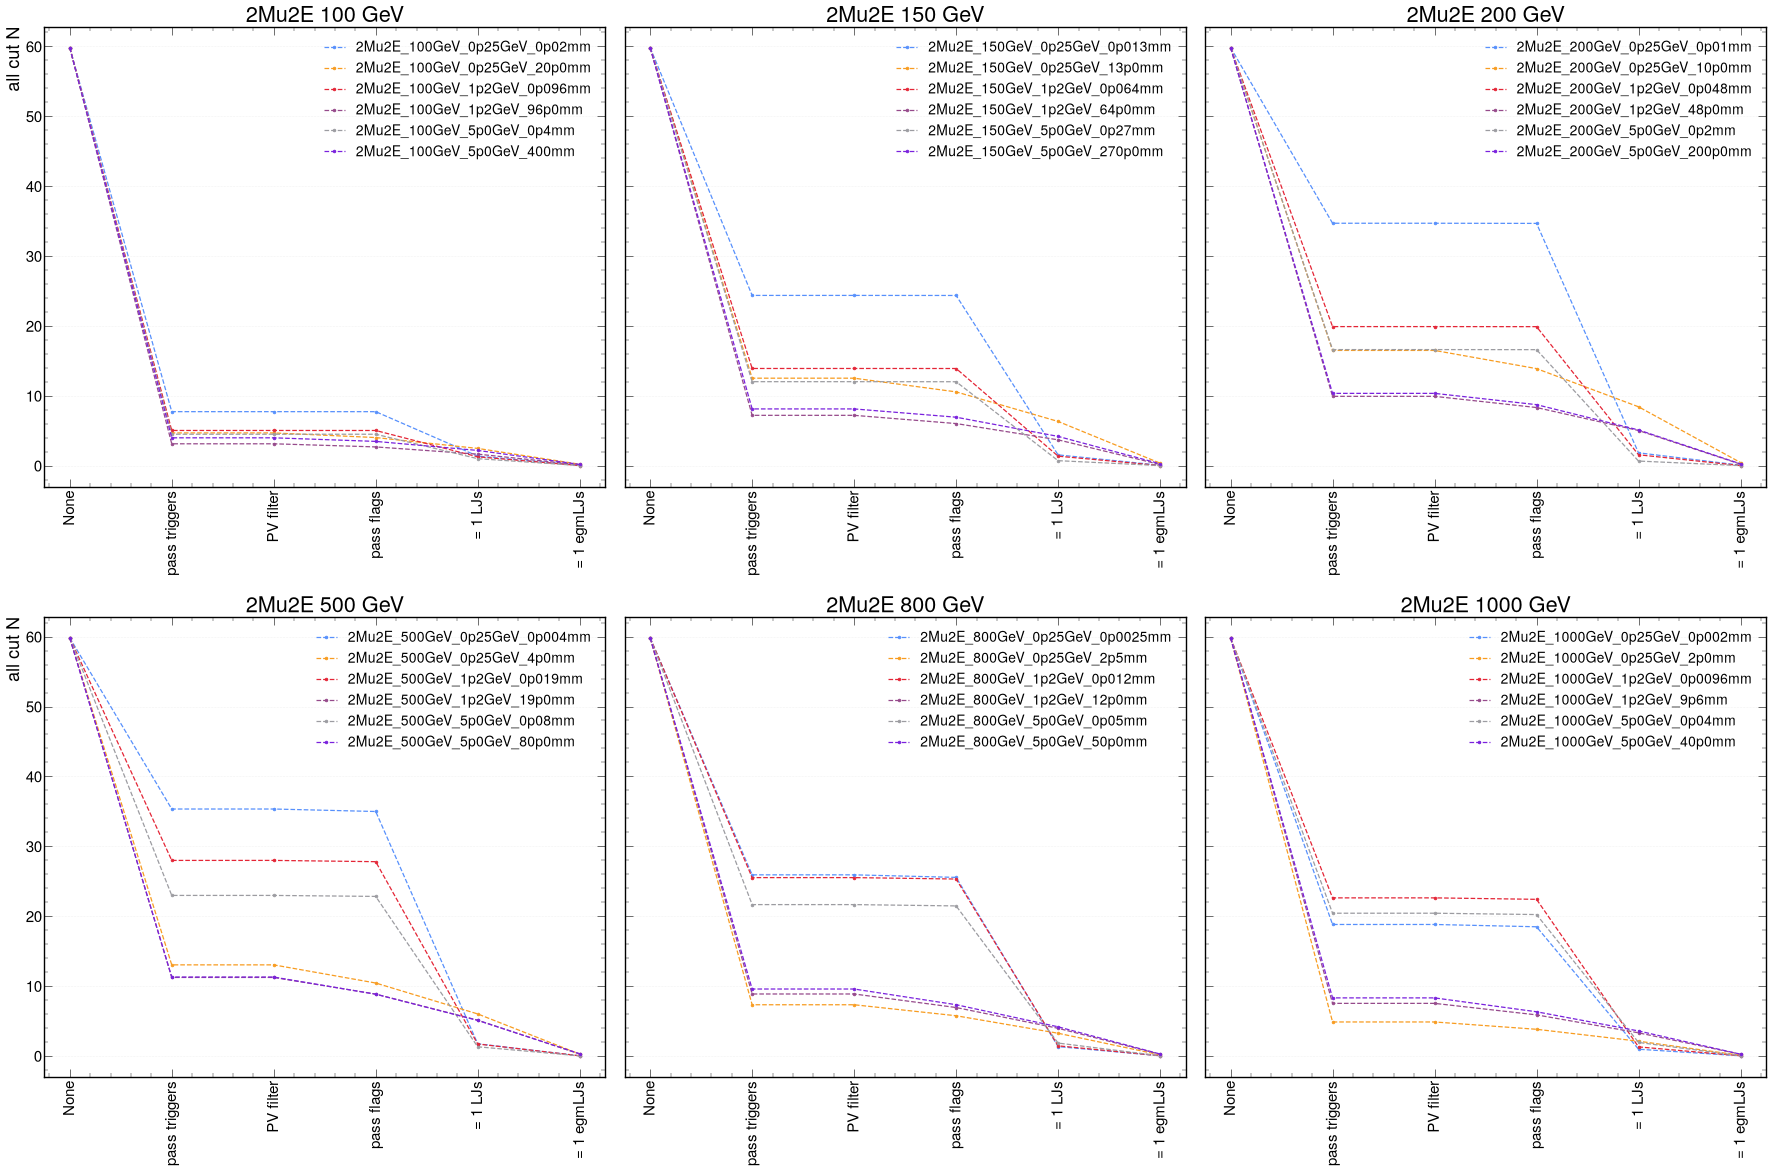

In [12]:
fig, axes = plot_cutflow_panels(
    out=out,
    sample_groups=[
        group1_2mu2e,
        group2_2mu2e,
        group3_2mu2e,
        group4_2mu2e,
        group5_2mu2e,
        group6_2mu2e,
    ],
    channel=channels[0],
    titles=[
        "2Mu2E 100 GeV",
        "2Mu2E 150 GeV",
        "2Mu2E 200 GeV",
        "2Mu2E 500 GeV",
        "2Mu2E 800 GeV",
        "2Mu2E 1000 GeV",
    ],
    unweighted=False,
    cumulative=True,
    normalize=False,
    logy=False,
    figsize=(36, 24),
    ncols=3,
    ncol_legend=1,
)

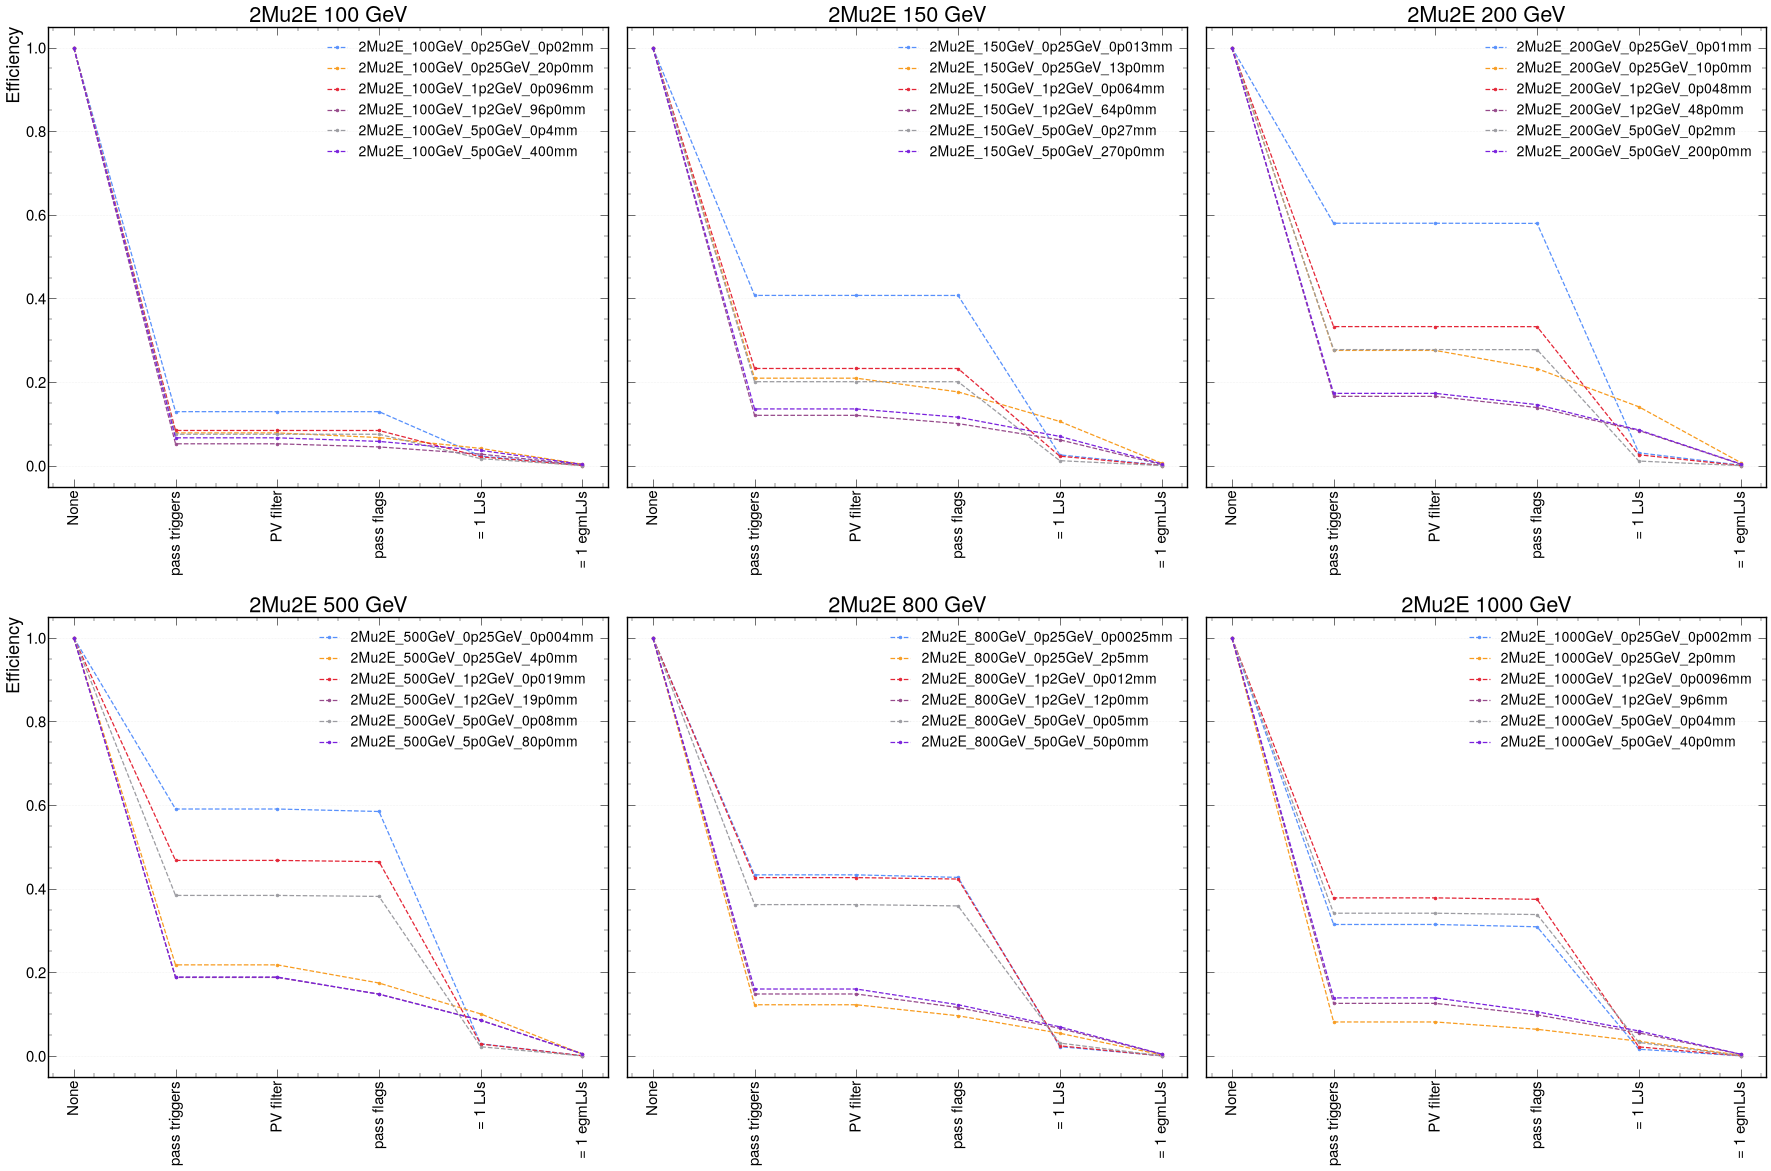

In [13]:
fig, axes = plot_cutflow_panels(
    out=out,
    sample_groups=[
        group1_2mu2e,
        group2_2mu2e,
        group3_2mu2e,
        group4_2mu2e,
        group5_2mu2e,
        group6_2mu2e,
    ],
    channel=channels[0],
    titles=[
        "2Mu2E 100 GeV",
        "2Mu2E 150 GeV",
        "2Mu2E 200 GeV",
        "2Mu2E 500 GeV",
        "2Mu2E 800 GeV",
        "2Mu2E 1000 GeV",
    ],
    unweighted=False,
    cumulative=True,
    normalize=True,
    logy=False,
    figsize=(36, 24),
    ncols=3,
    ncol_legend=1,
)

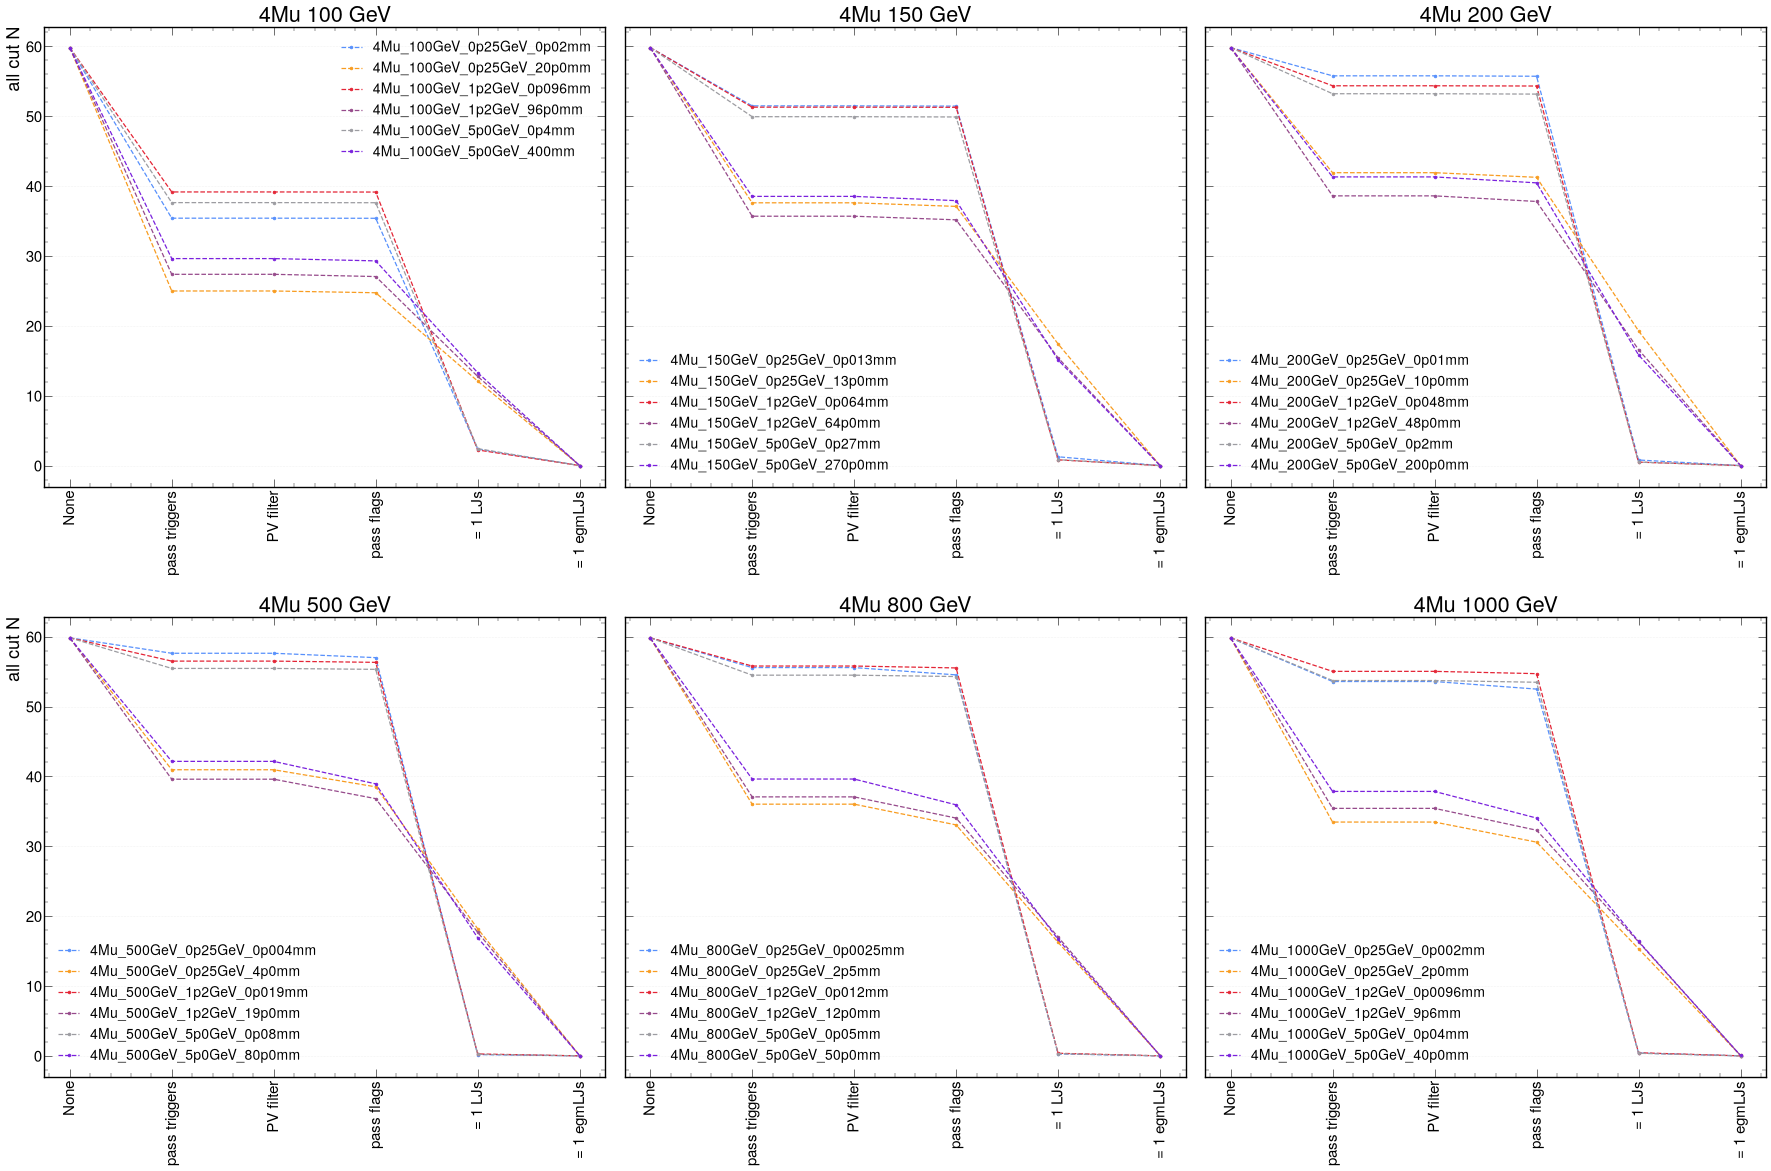

In [14]:
fig, axes = plot_cutflow_panels(
    out=out,
    sample_groups=[
        group1_4mu,
        group2_4mu,
        group3_4mu,
        group4_4mu,
        group5_4mu,
        group6_4mu,
    ],
    channel=channels[0],
    titles=[
        "4Mu 100 GeV",
        "4Mu 150 GeV",
        "4Mu 200 GeV",
        "4Mu 500 GeV",
        "4Mu 800 GeV",
        "4Mu 1000 GeV",
    ],
    unweighted=False,
    cumulative=True,
    normalize=False,
    logy=False,
    figsize=(36, 24),
    ncols=3,
    ncol_legend=1,
)

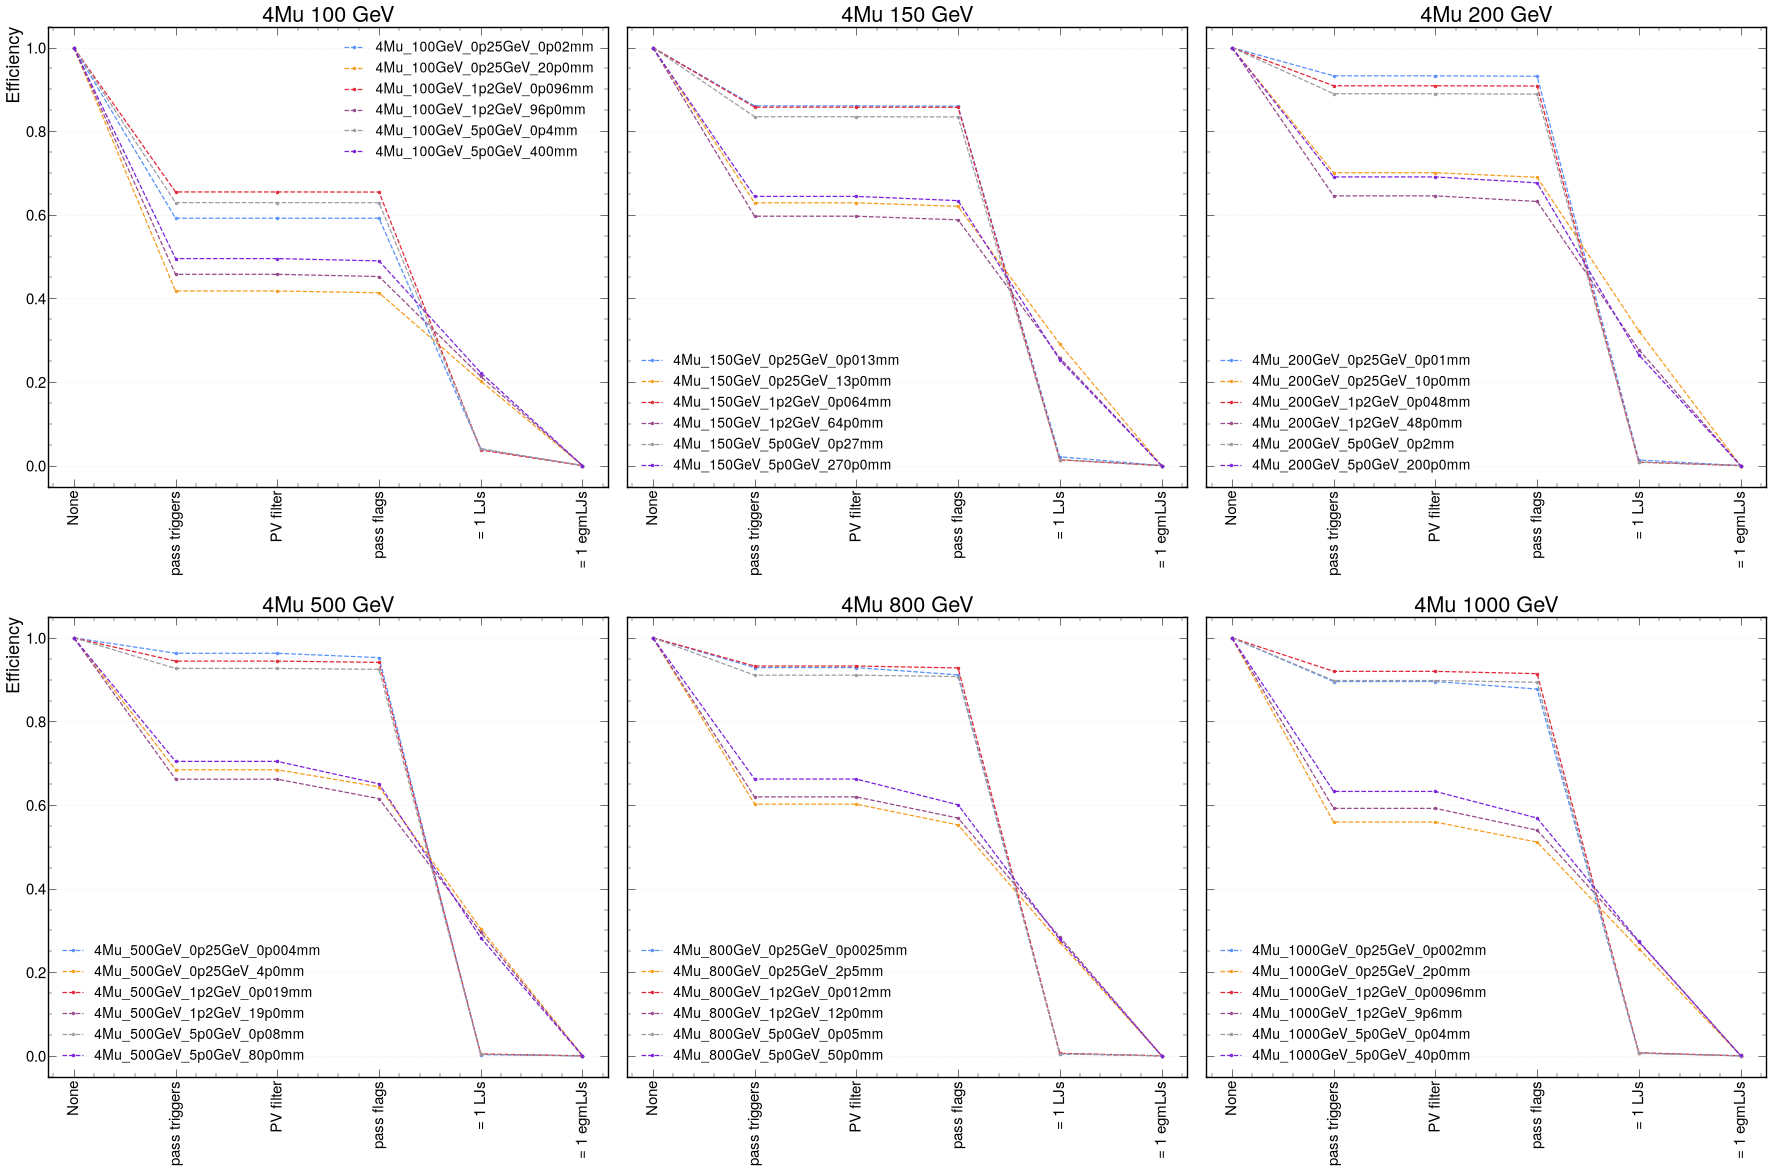

In [15]:
fig, axes = plot_cutflow_panels(
    out=out,
    sample_groups=[
        group1_4mu,
        group2_4mu,
        group3_4mu,
        group4_4mu,
        group5_4mu,
        group6_4mu,
    ],
    channel=channels[0],
    titles=[
        "4Mu 100 GeV",
        "4Mu 150 GeV",
        "4Mu 200 GeV",
        "4Mu 500 GeV",
        "4Mu 800 GeV",
        "4Mu 1000 GeV",
    ],
    unweighted=False,
    cumulative=True,
    normalize=True,
    logy=False,
    figsize=(36, 24),
    ncols=3,
    ncol_legend=1,
)

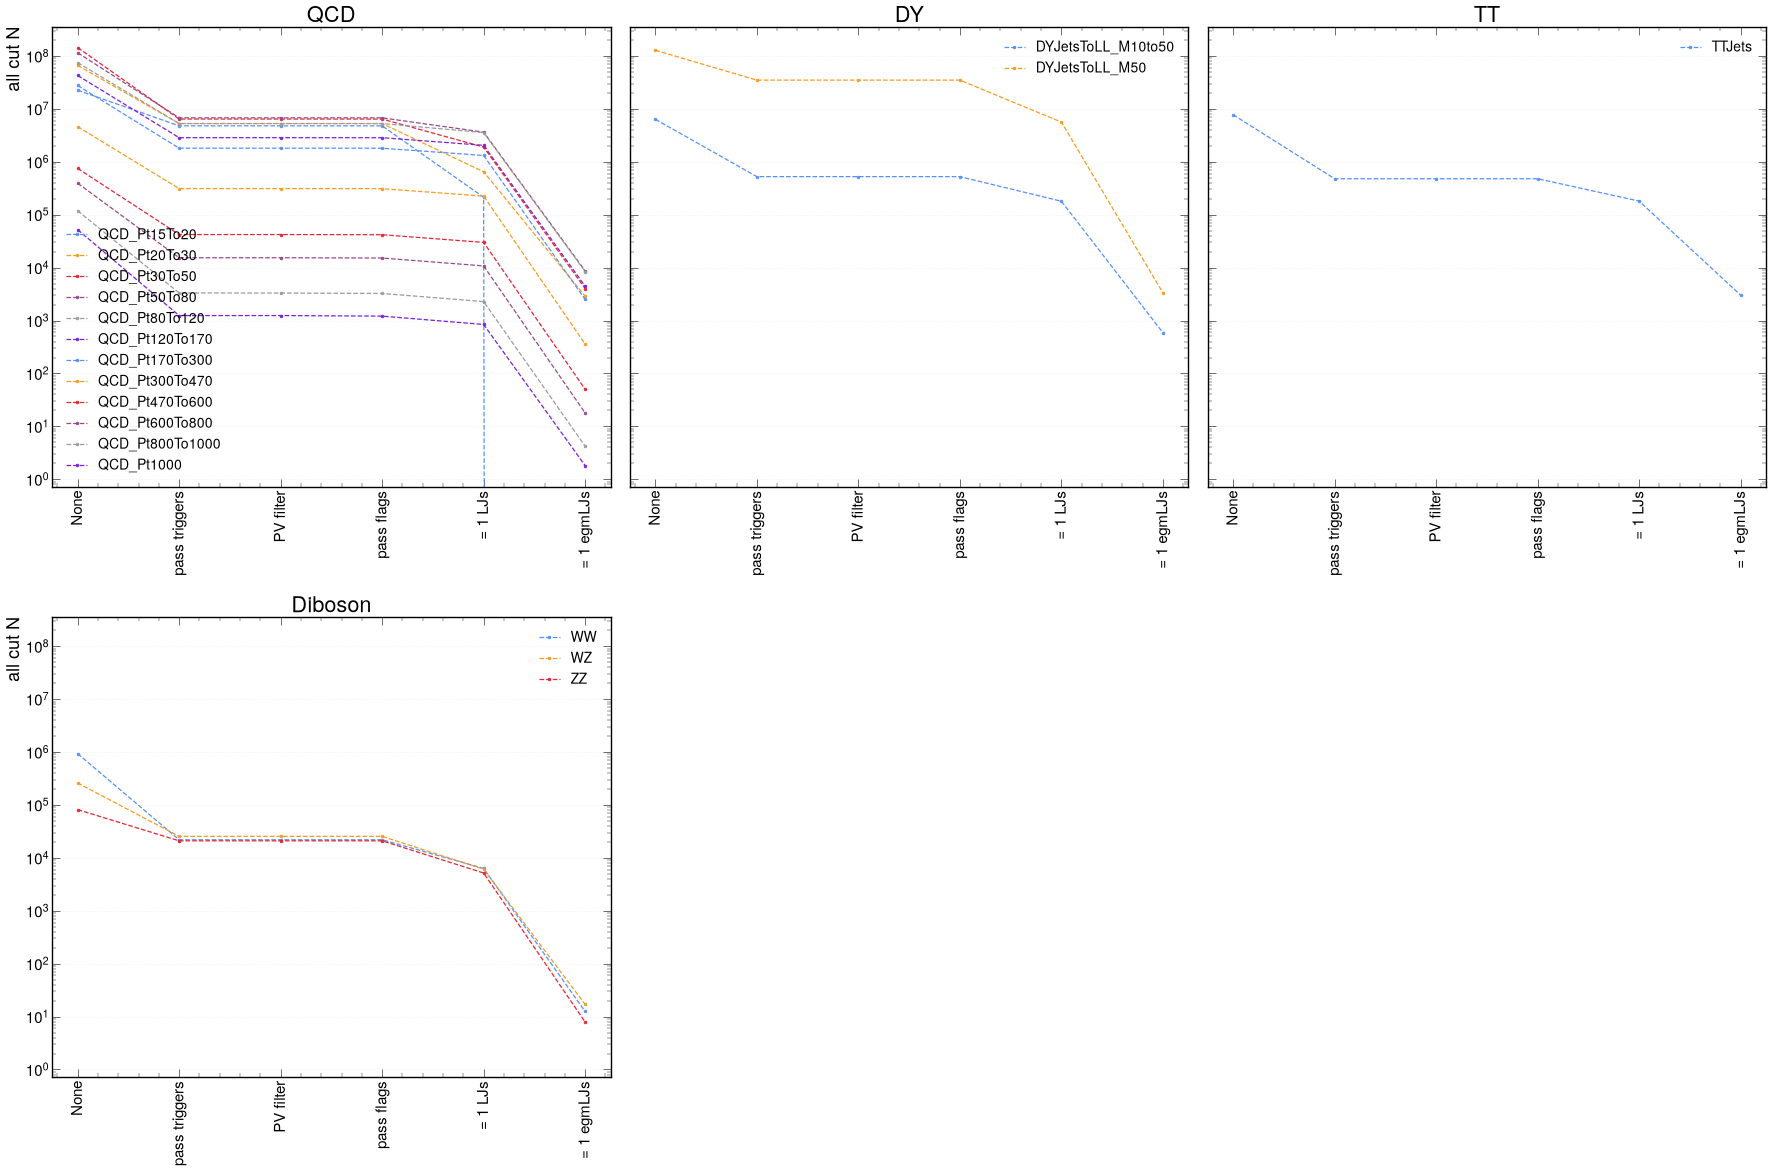

In [16]:
fig, axes = plot_cutflow_panels(
    out=out,
    sample_groups=[
        QCD,
        DY,
        TT,
        Diboson,
    ],
    channel=channels[0],
    titles=[
        "QCD",
        "DY",
        "TT",
        "Diboson",
    ],
    unweighted=False,
    cumulative=True,
    normalize=False,
    logy=True,
    figsize=(36, 24),
    ncols=3,
    ncol_legend=1,
)

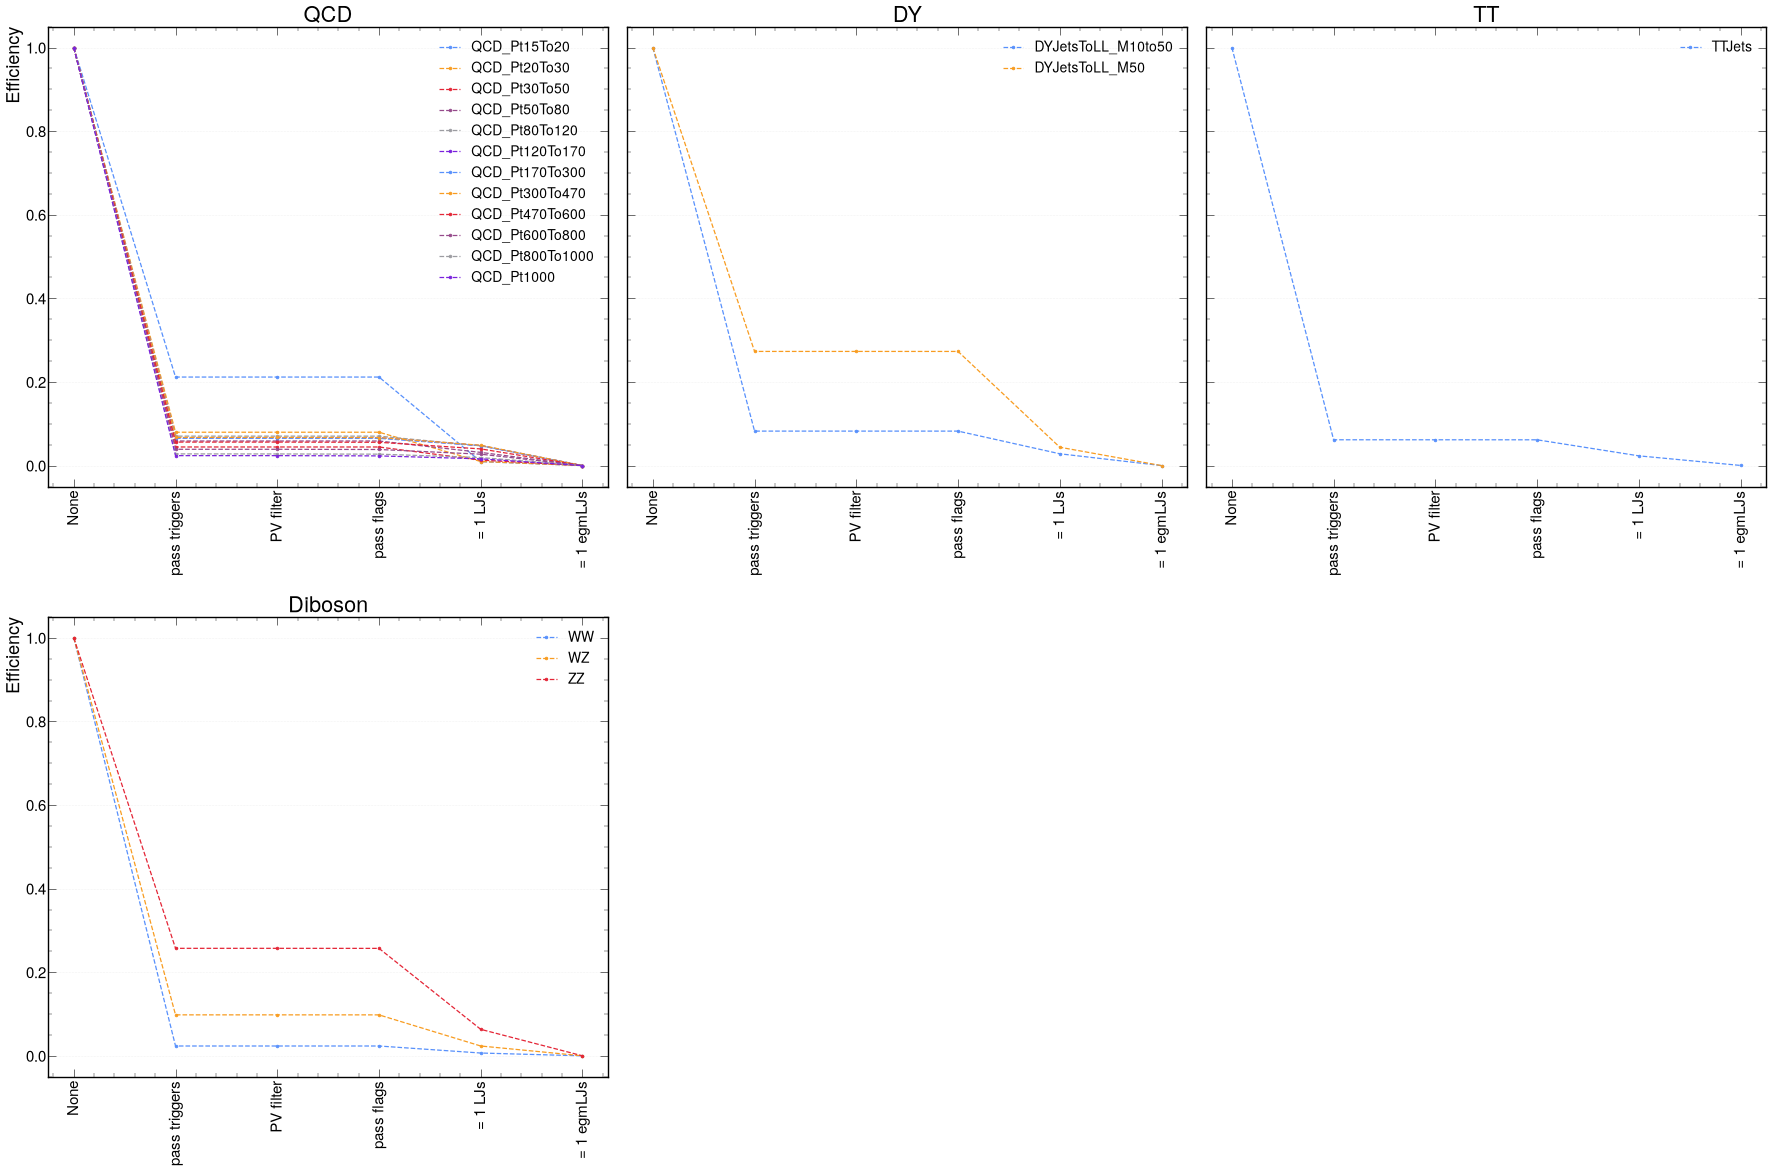

In [17]:
fig, axes = plot_cutflow_panels(
    out=out,
    sample_groups=[
        QCD,
        DY,
        TT,
        Diboson,
    ],
    channel=channels[0],
    titles=[
        "QCD",
        "DY",
        "TT",
        "Diboson",
    ],
    unweighted=False,
    cumulative=True,
    normalize=True,
    logy=False,
    figsize=(36, 24),
    ncols=3,
    ncol_legend=1,
)